In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load logged results
df = pd.read_json("../data/results.jsonl", lines=True)
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"✅ Loaded {len(df)} analysis records")
df.head()

✅ Loaded 4 analysis records


,overall_score,match_level,missing_skills,timestamp,word_count
0,82.4,Strong,[],2026-04-09 17:00:25.990878,84
1,44.7,Weak,"[excel, communication]",2026-04-09 17:01:31.186641,84
2,70.4,Strong,[],2026-04-09 17:02:07.008282,84
3,71.8,Strong,[],2026-04-09 17:02:54.047711,84


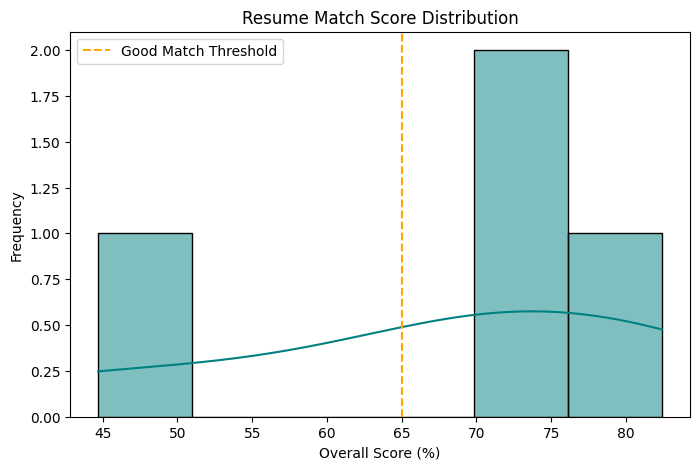

In [2]:
plt.figure(figsize=(8,5))
sns.histplot(df["overall_score"], bins=6, kde=True, color="teal")
plt.title("Resume Match Score Distribution")
plt.xlabel("Overall Score (%)")
plt.ylabel("Frequency")
plt.axvline(65, color="orange", linestyle="--", label="Good Match Threshold")
plt.legend()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_3424\716743186.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.values, y=missing_counts.index, palette="viridis")


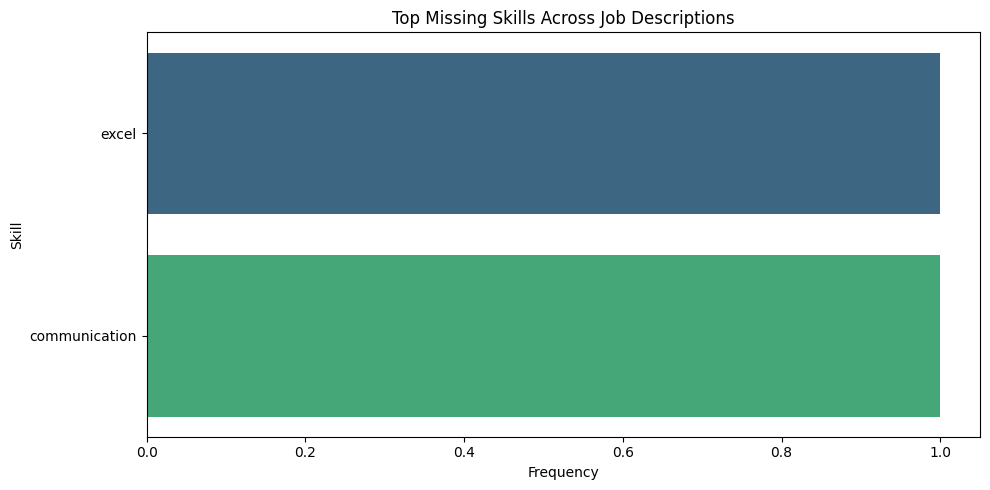

In [3]:
all_missing = df["missing_skills"].explode().dropna()
missing_counts = all_missing.value_counts().head(8)
plt.figure(figsize=(10,5))
sns.barplot(x=missing_counts.values, y=missing_counts.index, palette="viridis")
plt.title("Top Missing Skills Across Job Descriptions")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [4]:
print("📊 ANALYTICS SUMMARY")
print(f"Total Analyses: {len(df)}")
print(f"Average Match Score: {df['overall_score'].mean():.1f}%")
print(f"Strong Matches (>75%): {len(df[df['overall_score']>75])} ({len(df[df['overall_score']>75])/len(df)*100:.0f}%)")
if not all_missing.empty:
    print(f"Most Common Missing Skill: {all_missing.mode()[0]}")

📊 ANALYTICS SUMMARY
Total Analyses: 4
Average Match Score: 67.3%
Strong Matches (>75%): 1 (25%)
Most Common Missing Skill: communication
